<a href="https://colab.research.google.com/github/ljg7234/ViT/blob/main/ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self,in_channels = 3,patch_size = 16,emb_size = 768,img_size = 224):
        super().__init__()
        self.patch_size = patch_size
        self.projection = nn.Conv2d(in_channels,emb_size,kernel_size=patch_size,stride = patch_size)
        self.cls_token = nn.Parameter(torch.randn(1,1,emb_size))
        self.pos_indices = (img_size // patch_size) ** 2
        self.positions = nn.Parameter(torch.randn(self.pos_indices + 1,emb_size))

    def forward(self,x):
        b = x.shape[0]
        x = self.projection(x)
        x = x.flatten(2).transpose(1,2)

        cls_tokens = self.cls_token.expand(b,-1,-1)
        x = torch.cat([cls_tokens,x],dim = 1)

        x += self.positions
        return x

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self,emb_size = 768,num_heads = 8,dropout = 0.1):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        self.head_dim = emb_size // num_heads

        self.qkv = nn.Linear(emb_size,emb_size * 3)
        self.att_drop = nn.Dropout(dropout)
        self.projection = nn.Linear(emb_size,emb_size)

    def forward(self,x):
        b,n,e = x.shape
        qkv = self.qkv(x).reshape(b,n,3,self.num_heads,self.head_dim).permute(2,0,3,1,4)
        q,k,v = qkv[0],qkv[1],qkv[2]

        dot_product = torch.matmul(q,k.transpose(-2,-1))
        scaling = self.head_dim ** (0.5)
        att = (dot_product / scaling).softmax(dim = -1)
        att = self.att_drop(att)

        out = torch.matmul(att,v)
        out = out.transpose(1,2).reshape(b,n,e)
        return self.projection(out)


In [3]:
class TransformerBlock(nn.Module):
    def __init__(self,emb_size = 768,num_heads = 8,expansion = 4,dropout = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_size)
        self.attn = MultiHeadAttention(emb_size,num_heads,dropout)
        self.norm2 = nn.LayerNorm(emb_size)
        self.mlp = nn.Sequential(
            nn.Linear(emb_size,expansion * emb_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(expansion * emb_size,emb_size)
        )

    def forward(self,x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [4]:
class MyViT(nn.Module):
    def __init__(self,img_size = 72,patch_size = 8, in_channels = 3,num_classes = 10,emb_size =128,depth = 4,num_heads =8,dropout = 0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels,patch_size,emb_size,img_size)
        self.transformer = nn.Sequential(*[
            TransformerBlock(emb_size,num_heads,dropout = dropout) for _ in range(depth)
        ])
        self.head = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size,num_classes)
        )
    def forward(self,x):
        x = self.patch_embed(x)
        x = self.transformer(x)
        return self.head(x[:,0])

In [5]:
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((72,72)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data',train = True,download = True,transform = transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size = 64,shuffle = True)

100%|██████████| 170M/170M [07:37<00:00, 373kB/s]


In [11]:
model = MyViT(img_size = 72,patch_size = 8, emb_size = 128, depth = 4,num_heads = 8).to(device)
optimizer = optim.AdamW(model.parameters(),lr = 1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    model.train()
    total_loss,correct,total = 0,0,0
    print(f"\n[Epoch] {epoch+1}")

    for i,(inputs,labels) in enumerate(trainloader):
        inputs,labels = inputs.to(device),labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _,pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"Step [{i+1}/{len(trainloader)}] | Loss: {total_loss/100:.4f} | Acc: {100.*correct/total:.2f}%")
            total_loss, correct, total = 0, 0, 0


[Epoch] 1
Step [100/782] | Loss: 2.0517 | Acc: 23.08%
Step [200/782] | Loss: 1.8206 | Acc: 33.61%
Step [300/782] | Loss: 1.7265 | Acc: 36.84%
Step [400/782] | Loss: 1.6157 | Acc: 41.19%
Step [500/782] | Loss: 1.5576 | Acc: 43.95%
Step [600/782] | Loss: 1.5259 | Acc: 44.88%
Step [700/782] | Loss: 1.4922 | Acc: 45.02%

[Epoch] 2
Step [100/782] | Loss: 1.4037 | Acc: 48.75%
Step [200/782] | Loss: 1.4128 | Acc: 48.83%
Step [300/782] | Loss: 1.3759 | Acc: 50.09%
Step [400/782] | Loss: 1.3586 | Acc: 50.95%
Step [500/782] | Loss: 1.3245 | Acc: 52.27%
Step [600/782] | Loss: 1.3203 | Acc: 52.45%
Step [700/782] | Loss: 1.3167 | Acc: 52.81%

[Epoch] 3
Step [100/782] | Loss: 1.2574 | Acc: 54.38%
Step [200/782] | Loss: 1.2781 | Acc: 54.22%
Step [300/782] | Loss: 1.2326 | Acc: 56.09%
Step [400/782] | Loss: 1.2460 | Acc: 55.55%
Step [500/782] | Loss: 1.2398 | Acc: 55.31%
Step [600/782] | Loss: 1.2207 | Acc: 55.62%
Step [700/782] | Loss: 1.2160 | Acc: 56.11%

[Epoch] 4
Step [100/782] | Loss: 1.1460 | 

In [12]:
testset = torchvision.datasets.CIFAR10(root = './data',train = False,download= True,transform = transform)
testloader = torch.utils.data.DataLoader(testset,batch_size = 64,shuffle = 64)

model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images,labels in testloader:
        images,labels = images.to(device),labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs.data,1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
print(f'10,000개 테스트 이미지에 대한 최종 정확도: {100 * test_correct / test_total:.2f}%')

10,000개 테스트 이미지에 대한 최종 정확도: 67.46%


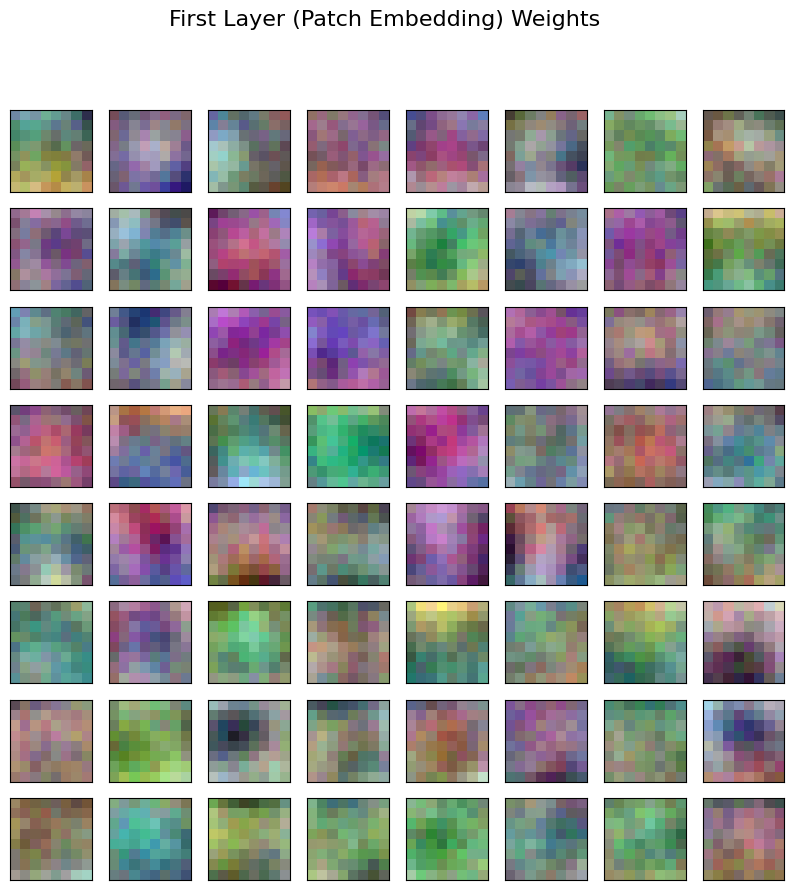

In [13]:
import matplotlib.pyplot as plt

weights = model.patch_embed.projection.weight.data.cpu()
weights_min,weights_max = weights.min(),weights.max()
weights = (weights - weights_min) / (weights_max - weights_min)

fig = plt.figure(figsize = (10,10))
for i in range(64):
    ax = fig.add_subplot(8,8,i+1,xticks = [],yticks = [])
    plt.imshow(weights[i].permute(1,2,0))
plt.suptitle("First Layer (Patch Embedding) Weights",fontsize = 16)
plt.show()